# TITAN 原理·玩具版：把整张切片压缩成一个"指纹"，能干什么？

> 这个 notebook 只回答一个问题：**切片级基础模型（slide foundation model）和 CLAM 有什么本质不同？它不看标签是怎么训练出"整张切片的通用表示"的？**
>
> 📚 玩具版系列第四篇（完结篇）。[CLAM 篇](CLAM_原理_玩具版.ipynb) 讲弱监督分类，[UNI2 篇](UNI2_原理_玩具版.ipynb) 讲 patch 级无标签特征，
> [CONCH 篇](CONCH_原理_玩具版.ipynb) 讲图文对齐。TITAN = 把这几篇的思想合起来，再往上走一层：**整张切片一个向量**。

**背景**：CLAM 是"每个任务从头训练一个专用小分类器"（每个任务 × 5 折都要 GPU 训练）。
TITAN（Nature Medicine 2025）换了个思路：**预训练一次**，把整张切片的所有 patch 特征交给一个 Transformer 消化，
输出一个"切片指纹"。之后检索相似病例、分类、预测生存期，都只是在这个指纹上接个线性层——甚至线性层都不用（检索）。

**你将看到**：
1. 造一批"有区域结构"的假切片（预训练**完全不用标签**）
2. 自监督任务："遮住四分之一的 patch，根据上下文猜回它们"——逼模型理解组织结构
3. 切片指纹的三大用法演示：**线性探测 / 相似病例检索 / 指纹空间可视化**

## 1. 问题设定 + 核心思想

这次的玩具世界比 CLAM 篇更逼真一点——**真实切片是有"区域结构"的**：一块肿瘤区域连着一片间质，而不是随机撒点。

- 每张切片 = **10 个区域 × 10 个 patch**（共 100 个，每个 4 维特征）
- 区域有组织类型：A（上皮样）/ B（间质样）/ **C（肿瘤样）**。同一区域内的 patch 长得像（这就是"上下文"）
- 正常切片：10 个区域全是 A/B；**肿瘤切片：其中 1 个区域是 C（占 10% 的 patch）**

标签这次**只在最后考试用**，预训练碰都不碰。

**核心思想：遮住重建（masked reconstruction）**

> 把一张切片随机遮住 25% 的 patch（换成一个特殊的"面具"占位符），
> 让模型**根据剩下的 75% 猜出被遮住的 patch 原来长什么样**。

为什么这会逼出"理解"？同一区域内的 patch 相似，所以想猜对被遮的 patch，模型必须学会"看周围是什么组织"——
这和人类学生做**完形填空**一个道理：会填空，说明真读懂了上下文。

**但有个前提：模型得知道每个 patch "坐在哪"。** 被遮住的 patch 全都换成同一个 [MASK] 令牌，
如果没有位置信息，所有被遮位置的输入一模一样，Transformer 只能给它们猜同一个答案（整张切片的"平均长相"），
根本不可能知道"我左右邻居是肿瘤区"。真实 TITAN 用 **2D ALiBi**：把两个 patch 之间的欧氏距离变成注意力分数上的减分项，
离得越远、注意力打的折扣越大。玩具里 patch 排成一行，就用 1D 距离 |i−j|。（第 2 节末尾有"拿掉位置信息"的对照实验。）

模型结构（一个迷你 Transformer）：
```
100 个 patch 特征(4维) → 投影到 16 维 → 队伍最前面加一个特殊的 [SLIDE] 令牌
→ Transformer（自注意力：每个 patch 都可以"看"所有其他 patch；ALiBi：patch 之间离得越远注意力越弱）
→ [SLIDE] 令牌的输出 = 整张切片的指纹（16 维）
```
`[SLIDE]` 令牌自己不携带任何 patch 信息，也不受距离惩罚，它存在的意义就是**旁听全场，然后代表整张切片发言**。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(42)

# ============ 造假切片：10 区域 × 10 patch，肿瘤切片含 1 个 C 区域 ============
N_REG, REG_LEN, DIM = 10, 10, 4
P3 = np.array([[2., 2., 0., 0.],     # A 上皮样
               [0., 0., 2., 2.],     # B 间质样
               [2., 0., 2., 0.]], dtype=np.float32)   # C 肿瘤样
REG_NAMES = ['A(上皮样)', 'B(间质样)', 'C(肿瘤样)']

def make_slide(tumor, r):
    types = ([2] + list(r.choice([0, 1], N_REG - 1))) if tumor else list(r.choice([0, 1], N_REG))
    r.shuffle(types)
    feats = np.concatenate([P3[t] + r.normal(0, 0.4, (REG_LEN, DIM)) for t in types]).astype(np.float32)
    return feats, types

r = np.random.default_rng(42)
bags, types_list = [], []
for i in range(200):
    f, t = make_slide(i >= 100, r)          # 前 100 正常，后 100 肿瘤
    bags.append(f); types_list.append(t)
labels = np.array([i >= 100 for i in range(200)])   # 锁进保险柜 🔒，预训练不用
X = torch.from_numpy(np.stack(bags))                # (200 张, 100 patch, 4 维)

print('数据集:', tuple(X.shape), '（标签已锁进保险柜 🔒）')
print('切片 150（肿瘤）的 10 个区域类型:', [REG_NAMES[t] for t in types_list[150]])
print('切片 3（正常）的 10 个区域类型:  ', [REG_NAMES[t] for t in types_list[3]])

数据集: (200, 100, 4) （标签已锁进保险柜 🔒）
切片 150（肿瘤）的 10 个区域类型: ['C(肿瘤样)', 'A(上皮样)', 'B(间质样)', 'A(上皮样)', 'A(上皮样)', 'A(上皮样)', 'A(上皮样)', 'A(上皮样)', 'A(上皮样)', 'B(间质样)']
切片 3（正常）的 10 个区域类型:   ['B(间质样)', 'A(上皮样)', 'B(间质样)', 'A(上皮样)', 'B(间质样)', 'B(间质样)', 'A(上皮样)', 'A(上皮样)', 'B(间质样)', 'B(间质样)']


## 2. 搭建迷你 TITAN + 遮住重建训练

玩具版的训练目标（三个零件）：
- **遮住**：随机 25% patch 的特征被替换成可学习的 [MASK] 令牌（模型看不见它们的原值）
- **猜回**：Transformer 输出每个位置的预测，和原值算 MSE（只有被遮住的位置计分）
- **切片级一致性**：同一张切片的两次独立遮挡，[SLIDE] 指纹要一致；不同切片的指纹要不同（对比损失）
  （没有这一条，[SLIDE] 令牌没有动力记录"这张切片整体是什么"——它完全可以只顾局部重建）
- **副产品**：`[SLIDE]` 令牌的输出就是切片指纹——训练完白捡的

⚖️ **和真实 TITAN 第一阶段（TITAN-V）的差别**：真实 TITAN 用的是 **iBOT**。
① 局部任务不是"猜回原始特征值"：学生网络对被遮住的 patch 令牌，预测的是**老师网络**（学生参数的滑动平均）
在没遮挡版本上输出的概率分布；② 全局一致性也是老师-学生自蒸馏（DINO 式），不用负样本；
③ "两次观察"来自在 16×16 的特征网格上随机裁剪（2 个 14×14 的全局视角 + 10 个 6×6 的局部视角），再加翻转和 posterization 特征增强。
玩具版换成更直观的 MSE 重建 + 对比损失，想达到的效果相同：**局部能根据上下文猜，整体能认出是哪张切片**。

参照系（看重建误差时心里要有这三把尺子）：
- 下限：同一区域内 patch 的噪声 σ=0.4，就算完全猜对区域类型，误差也有 0.4² ≈ **0.16**
- 只知道整张切片"平均长什么样"、不知道被遮 patch 在哪个区域：≈ **1.1**（A/B 两种区域在每一维上相差 2，方差约 1，再加噪声 0.16）
- 闭眼瞎猜（全猜 0）：下面的 `baseline`

In [2]:
class TinyTITAN(nn.Module):
    """玩具版切片编码器。真实 TITAN: 输入是 CONCHv1.5 的 768 维 patch 特征（2D 网格），6 层 ViT + 2D ALiBi。"""
    def __init__(self, dim_in=4, d=16, nhead=4, use_alibi=True, slope=0.5):
        super().__init__()
        self.proj = nn.Linear(dim_in, d)                      # patch 特征 4 → 16 维
        self.slide_tok = nn.Parameter(torch.randn(1, 1, d) * 0.02)  # [SLIDE] 令牌：代表整张切片发言
        self.mask_tok  = nn.Parameter(torch.randn(1, 1, d) * 0.02)  # [MASK] 令牌："此处被遮住"的占位符
        layer = nn.TransformerEncoderLayer(d, nhead, dim_feedforward=64, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=1)   # 自注意力：patch 们互相"看"
        self.head = nn.Linear(d, dim_in)                      # 重建头：16 维 → 猜回 4 维原值
        # ALiBi 距离偏置：patch i 看 patch j 时，注意力分数减去 slope×|i−j|（离得越远折扣越大）
        # [SLIDE] 令牌（第 0 位）和谁之间都不减分。它是固定的常数，不是可学习参数。
        L = N_REG * REG_LEN
        pos = torch.arange(L, dtype=torch.float32)
        bias = torch.zeros(L + 1, L + 1)
        if use_alibi:
            bias[1:, 1:] = -slope * (pos[:, None] - pos[None, :]).abs()
        self.register_buffer('alibi', bias)

    def forward(self, x, mask):
        h = self.proj(x)                       # (B, 100, 16)
        h[mask] = self.mask_tok.reshape(-1)    # 被遮住的位置换成 [MASK] 令牌
        seq = torch.cat([self.slide_tok.expand(len(x), -1, -1), h], dim=1)  # [SLIDE] 坐排头
        out = self.encoder(seq, mask=self.alibi)   # (B, 101, 16)；mask 传入的浮点矩阵会加到注意力分数上
        return out[:, 0], self.head(out[:, 1:])    # 切片指纹, 每个 patch 的重建值

def slide_closs(e1, e2, tau=0.3):
    """切片级对比：一批 16 张切片 × 2 次遮挡 = 32 个指纹，每个指纹在其余 31 个里找出自己的另一半——31 选 1 的 softmax。"""
    B = len(e1)
    z = F.normalize(torch.cat([e1, e2]), dim=1)
    sim = z @ z.T / tau
    sim.fill_diagonal_(-1e9)
    t = torch.cat([torch.arange(B) + B, torch.arange(B)])
    return F.cross_entropy(sim, t)

def pretrain(model, epochs, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    n_batch = int(np.ceil(len(X) / 16))
    for ep in range(epochs):
        perm = torch.randperm(len(X))
        tot_r, tot_c = 0.0, 0.0
        for i in range(0, len(X), 16):             # 每批 16 张切片
            xb = X[perm[i:i+16]]
            m1 = torch.rand(xb.shape[:2]) < 0.25   # 第一次独立遮挡
            m2 = torch.rand(xb.shape[:2]) < 0.25   # 第二次独立遮挡
            e1, recon = model(xb, m1)              # 视角 1：指纹 + 重建
            e2, _     = model(xb, m2)              # 视角 2：只要指纹
            l_rec  = F.mse_loss(recon[m1], xb[m1]) # 局部：被遮 patch 猜回原值
            l_con  = slide_closs(e1, e2)           # 全局：同一张切片的两个指纹要一致
            loss = l_rec + 0.3 * l_con
            opt.zero_grad(); loss.backward(); opt.step()
            tot_r += l_rec.item(); tot_c += l_con.item()
        if ep % log_every == log_every - 1:
            print(f'epoch {ep+1:3d}: 重建误差 = {tot_r/n_batch:.3f} (下限≈0.16, 只知平均≈1.1, 瞎猜≈{baseline:.2f})'
                  f' | 切片对比损失 = {tot_c/n_batch:.3f} (瞎猜={np.log(31):.2f})')
    return tot_r / n_batch

baseline = (X ** 2).mean().item()
model = TinyTITAN()
print(f'参数量: {sum(p.numel() for p in model.parameters()):,}  (真实 TITAN 的切片编码器约 4850 万参数，是这个的 1.4 万倍)')
print(f'闭眼瞎猜（全猜 0）的重建误差 ≈ {baseline:.2f}   ← 参照系')
pretrain(model, epochs=400)

参数量: 3,460  (真实 TITAN 的切片编码器约 4850 万参数，是这个的 1.4 万倍)
闭眼瞎猜（全猜 0）的重建误差 ≈ 2.16   ← 参照系


epoch 100: 重建误差 = 0.317 (下限≈0.16, 只知平均≈1.1, 瞎猜≈2.16) | 切片对比损失 = 1.789 (瞎猜=3.43)


epoch 200: 重建误差 = 0.305 (下限≈0.16, 只知平均≈1.1, 瞎猜≈2.16) | 切片对比损失 = 1.765 (瞎猜=3.43)


epoch 300: 重建误差 = 0.301 (下限≈0.16, 只知平均≈1.1, 瞎猜≈2.16) | 切片对比损失 = 1.769 (瞎猜=3.43)


epoch 400: 重建误差 = 0.293 (下限≈0.16, 只知平均≈1.1, 瞎猜≈2.16) | 切片对比损失 = 1.688 (瞎猜=3.43)


0.2934770996753986

### 2b. 对照实验：拿掉位置信息会怎样？

同样的模型、同样的训练，只是不加 ALiBi 距离偏置（`use_alibi=False`）。为了省时间只训 100 轮——它很快就卡住不动了。

In [3]:
model_nopos = TinyTITAN(use_alibi=False)
err_nopos = pretrain(model_nopos, epochs=100)
print(f'→ 没有位置信息时重建误差停在 {err_nopos:.2f} 左右，正好是"只知道整张切片平均长相"的水平：')
print('  被遮住的 patch 输入全是同一个 [MASK]，模型分不清它们各自在哪个区域，只能给出同一个答案。')

epoch 100: 重建误差 = 1.067 (下限≈0.16, 只知平均≈1.1, 瞎猜≈2.16) | 切片对比损失 = 1.857 (瞎猜=3.43)
→ 没有位置信息时重建误差停在 1.07 左右，正好是"只知道整张切片平均长相"的水平：
  被遮住的 patch 输入全是同一个 [MASK]，模型分不清它们各自在哪个区域，只能给出同一个答案。


## 3. 切片指纹的第一次考试：线性探测

预训练结束，`[SLIDE]` 令牌输出每张切片一个 16 维指纹。**现在才开锁标签** 🔓——
在指纹上训一个最普通的逻辑回归（150 张训练 / 50 张考试，分层抽样两类各半），和"笨办法"（100 个 patch 直接取平均）对比。

⚖️ 先说句实话：这批玩具数据的类别差异是"组织构成"（肿瘤切片多 10% 的 C 区域），取平均也能捕捉到一部分——
所以取平均不会太差。真实切片里诊断依据又少又微妙时平均就失效了（回忆 CLAM 篇第 6 节：肿瘤占比降到几个百分点时，取平均的测试准确率明显掉队）。
**重点不是碾压取平均，而是：预训练完全没看标签，指纹却已经把两类基本分开了。**
（还要注意：自监督预训练用了全部 200 张切片，包括后面考试用的 50 张——只是没用它们的标签。真实 TITAN 的评测集和预训练集是分开的。）

取平均 + 逻辑回归:        96.0%
TITAN 式切片指纹 + 逻辑回归: 100.0%   ← 预训练没见过标签


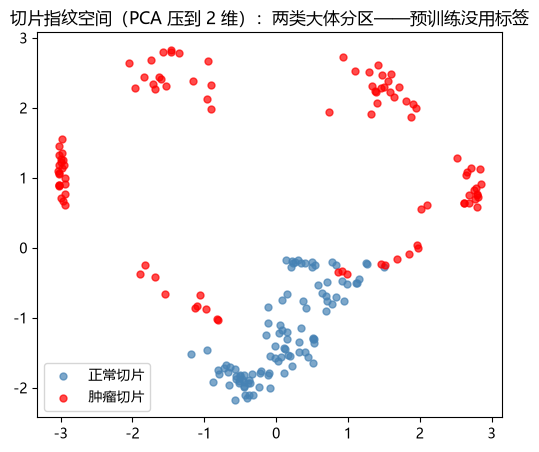

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

model.eval()                                          # 推理模式：关掉 Transformer 里的 dropout，否则每次提的指纹都带随机噪声
with torch.no_grad():
    slide_emb, _ = model(X, torch.zeros(X.shape[:2], dtype=torch.bool))  # 推理时不遮任何东西
slide_emb = slide_emb.numpy()
mean_pool = X.mean(dim=1).numpy()                     # 对照组：直接平均

e_tr, e_te, y_tr, y_te = train_test_split(slide_emb, labels, test_size=0.25, random_state=0, stratify=labels)
m_tr, m_te, _, _ = train_test_split(mean_pool, labels, test_size=0.25, random_state=0, stratify=labels)

acc_mean = LogisticRegression(max_iter=1000).fit(m_tr, y_tr).score(m_te, y_te)
acc_titan = LogisticRegression(max_iter=1000).fit(e_tr, y_tr).score(e_te, y_te)
print(f'取平均 + 逻辑回归:        {acc_mean:.1%}')
print(f'TITAN 式切片指纹 + 逻辑回归: {acc_titan:.1%}   ← 预训练没见过标签')

# 把 16 维指纹压到 2 维看看
Z = PCA(2).fit_transform(slide_emb)
plt.figure(figsize=(6, 5))
plt.scatter(Z[~labels, 0], Z[~labels, 1], s=25, alpha=0.7, c='steelblue', label='正常切片')
plt.scatter(Z[labels, 0], Z[labels, 1], s=25, alpha=0.7, c='red', label='肿瘤切片')
plt.legend(); plt.title('切片指纹空间（PCA 压到 2 维）：两类大体分区——预训练没用标签')
plt.show()

## 4. 第二次考试：相似病例检索（连线性层都不用）

指纹空间的另一个免费能力：**找相似病例**。随便挑一张肿瘤切片当"查询"，找指纹最像的 5 张，看它们是什么。
临床意义：遇到疑难病例，秒级从数据库捞出"最相似的既往病例"参考——真实病理工作流里非常值钱。
作为对照，同样用"100 个 patch 取平均"当指纹也检索一遍。

In [5]:
q = 150                                                  # 拿第 150 张（肿瘤切片）当查询
sims = (slide_emb @ slide_emb[q]) / (np.linalg.norm(slide_emb, axis=1) * np.linalg.norm(slide_emb[q]) + 1e-9)
sims[q] = -1                                             # 排除它自己
top5 = sims.argsort()[::-1][:5]
print(f'查询: 第 {q} 张切片（肿瘤）')
print('最相似的 5 张:')
for rank, i in enumerate(top5, 1):
    print(f'  #{rank}: 切片 {int(i):3d}  相似度 {sims[i]:.3f}  标签={"肿瘤" if labels[i] else "正常"}')
print()
n_tumor = int(labels[top5].sum())
print(f'命中 {n_tumor}/5 张肿瘤 → 指纹空间按"切片像不像"组织好了')

# 对照：取平均当指纹，并把每张肿瘤切片都当一次查询，算平均命中率（比只看一张更可靠）
def hit_rate(emb):
    e = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    S = e @ e.T
    np.fill_diagonal(S, -1)
    top = np.argsort(-S, axis=1)[:, :5]
    return labels[top][labels].mean()            # 所有肿瘤查询的 top-5 里肿瘤的比例
print(f'所有 100 张肿瘤切片轮流当查询，top-5 命中率: TITAN 式指纹 {hit_rate(slide_emb):.1%} | 取平均 {hit_rate(mean_pool):.1%}')

查询: 第 150 张切片（肿瘤）
最相似的 5 张:
  #1: 切片 101  相似度 0.998  标签=肿瘤
  #2: 切片 171  相似度 0.980  标签=肿瘤
  #3: 切片 103  相似度 0.970  标签=肿瘤
  #4: 切片 119  相似度 0.962  标签=肿瘤
  #5: 切片 124  相似度 0.955  标签=肿瘤

命中 5/5 张肿瘤 → 指纹空间按"切片像不像"组织好了
所有 100 张肿瘤切片轮流当查询，top-5 命中率: TITAN 式指纹 100.0% | 取平均 95.8%


## 5. 诚实声明：玩具版 vs 真实 TITAN

| | 玩具版（本 notebook） | 真实 TITAN |
|---|---|---|
| 输入 | 4 维假 patch 特征 × 100 个 | **CONCHv1.5 提取的 768 维 patch 特征**（512×512 像素 @20×，排成 2D 网格），一张切片几千上万个 |
| 位置信息 | 1D ALiBi（patch 排成一行，距离 = \|i−j\|） | **2D ALiBi**（距离 = patch 间欧氏距离）；训练时用 16×16 网格裁剪出的短序列，推理时外推到整张切片 |
| 预训练任务 | 遮住重建（MSE）+ 切片级对比 | **三阶段**：① TITAN-V：在特征网格上做 iBOT（被遮令牌和全局令牌的老师-学生自蒸馏）② 8192×8192 像素 ROI ↔ 42.3 万条 PathChat 生成的合成描述对齐 ③ 整张切片 ↔ 18.3 万份病理报告对齐（②③ 都用 CoCa，即 CONCH 篇的对比 + 生成） |
| 切片指纹 | 16 维 | **768 维** |
| 训练数据 | 200 张假切片 | **Mass-340K：335,645 张切片**，20 种器官（H&E 89.7% / IHC 7.9% / 特殊染色 2.3%） |
| 模型 | 1 层 Transformer，3,460 个参数 | 6 层 ViT（12 个注意力头，768 维），约 4850 万参数 |

**TITAN 论文里展示的能力**（玩具版只演示了前两个）：线性探测分类、切片检索（包括罕见病检索）、少样本分类、
**用文字 prompt 做零样本分类**和跨模态检索（阶段③的遗产）、病理报告生成、生存预测（在指纹上接线性 Cox 模型）。

> ⚖️ 诚实的简化：玩具版只模仿了阶段①的思路，而且把 iBOT 的自蒸馏换成了 MSE 重建 + 对比损失；没有文本对齐。
> 但"切片指纹"这个核心概念是完整保留的——真实 TITAN 的检索和线性探测用法和玩具里一模一样，只是维度从 16 换成 768。

**系列全景**（四个模型在流水线里的位置）：
```
WSI → 切块 → [UNI2 / CONCH: patch → 特征向量] → [TITAN: 所有 patch → 切片指纹] → 下游随便接
                        ↘ 或者 → [CLAM: 注意力 MIL] → 专用分类器 + 注意力热图
```

## 6. 三句话小结

1. **CLAM 与 TITAN 的分工**：CLAM = 为每个任务训练专用小分类器（可解释：有热图）；TITAN = 预训练一次得到通用切片指纹（下游零样本/少样本直接用）。
2. **遮住重建 = 完形填空**：不看标签，靠"根据上下文猜回被遮的 patch"就能学会组织结构的规律——前提是模型知道每个 patch 在哪（位置编码；第 2b 节拿掉它，模型就只能猜平均）。
3. **趋势是叠加而非替代**：TITAN 站在 CONCH（patch 特征 + 文本对齐）的肩膀上，CONCH 站在 UNI 式自监督的肩膀上——这个系列的四个 notebook 就是这条进化链。

→ 回到工程实战：[CLAM_workflow.ipynb](CLAM_workflow.ipynb) 用真实 TCGA 数据把整条流水线跑一遍。